In [1]:
# user_logs.csv 컬럼 설명
# msno       : 유저 고유 ID (한 유저가 여러 날짜에 걸쳐 여러 행을 가짐 -> 이 테이블의 PK가 아님)
# date       : 로그 날짜 (YYYYMMDD)
# num_25     : 그 날 재생 시간이 곡 길이의 0~25% 미만이었던 곡 수
# num_50     : 25~50% 재생한 곡 수
# num_75     : 50~75% 재생한 곡 수
# num_985    : 75~98.5% 재생한 곡 수
# num_100    : 98.5% 이상(사실상 완청) 재생한 곡 수
# num_unq    : 그 날 재생한 고유 곡 수
# total_secs : 그 날 총 재생 시간(초). 데이터에 음수/센티넬 등 손상된 값이 섞여 있어 이상치 처리 필요

In [2]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 시각화 스타일 (팔레트: series-1 blue #2a78d6, 그리드 #e1e0d9, 축 #c3c2b7)
# sns.set_style를 먼저 호출한 뒤 rcParams.update를 마지막에 적용해야
# seaborn이 font.family를 sans-serif로 되돌리는 것을 막을 수 있음
sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",  # 한글 라벨 깨짐 방지 (Windows 기본 한글 폰트)
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})

SERIES_1 = "#2a78d6"
CUTOFF_DATE = pd.Timestamp("2017-01-31")
CUTOFF_INT = int(CUTOFF_DATE.strftime("%Y%m%d"))
pd.set_option("display.max_columns", None)

In [3]:
# user_logs.csv는 약 30GB/3억 9천만 행이라 한 번에 메모리에 올릴 수 없다.
# 그래서 파일을 청크(chunk) 단위로 딱 한 번만 순회하면서 필요한 통계를
# 누적(accumulate)하는 방식으로 EDA를 진행한다.

CHUNK_SIZE = 10_000_000
RATIO_COLS = ["num_25", "num_50", "num_75", "num_985", "num_100"]
STAT_COLS = RATIO_COLS + ["num_unq"]

TOTAL_SECS_CAP = 86400 * 2  # 이상치 컷오프: 하루 청취시간의 2배까지만 유효하다고 간주

total_secs_bins = np.linspace(0, 86400, 61)
num_unq_bins = np.linspace(0, 500, 51)

raw_n_rows = 0
post_cutoff_rows = 0
n_rows = 0  # 2017-01-31까지의 실제 분석 행 수
missing_counts = pd.Series(
    0, index=["msno", "date", "num_25", "num_50", "num_75", "num_985", "num_100", "num_unq", "total_secs"]
)
user_logday_counts = pd.Series(dtype="float64")
daily_counts = pd.Series(dtype="float64")

neg_total_secs = 0
over_cap_total_secs = 0
neg_num_cols = 0

stat_sum = {c: 0.0 for c in STAT_COLS}
stat_sumsq = {c: 0.0 for c in STAT_COLS}
stat_min = {c: np.inf for c in STAT_COLS}
stat_max = {c: -np.inf for c in STAT_COLS}

total_secs_sum = 0.0
total_secs_sumsq = 0.0
total_secs_valid_n = 0
total_secs_hist = np.zeros(len(total_secs_bins) - 1, dtype="int64")
num_unq_hist = np.zeros(len(num_unq_bins) - 1, dtype="int64")

print("누적기 초기화 완료")

누적기 초기화 완료


In [4]:
import pickle

RAW_DIR = Path("../data/raw").resolve()
CACHE_PATH = Path("../data/processed/user_logs_eda_cache_20170131.pkl")
CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

if CACHE_PATH.exists():
    with open(CACHE_PATH, "rb") as f:
        cache = pickle.load(f)
    (raw_n_rows, post_cutoff_rows, n_rows, missing_counts, user_logday_counts, daily_counts,
     neg_total_secs, over_cap_total_secs, neg_num_cols,
     stat_sum, stat_sumsq, stat_min, stat_max,
     total_secs_sum, total_secs_sumsq, total_secs_valid_n,
     total_secs_hist, num_unq_hist) = (
        cache["raw_n_rows"], cache["post_cutoff_rows"], cache["n_rows"],
        cache["missing_counts"], cache["user_logday_counts"], cache["daily_counts"],
        cache["neg_total_secs"], cache["over_cap_total_secs"], cache["neg_num_cols"],
        cache["stat_sum"], cache["stat_sumsq"], cache["stat_min"], cache["stat_max"],
        cache["total_secs_sum"], cache["total_secs_sumsq"], cache["total_secs_valid_n"],
        cache["total_secs_hist"], cache["num_unq_hist"],
    )
    print(f"캐시 로드 완료: 분석 대상 {n_rows:,} 행 (전체 재스캔 생략, {CACHE_PATH})")
else:
    t0 = time.time()
    reader = pd.read_csv(RAW_DIR / "user_logs.csv", chunksize=CHUNK_SIZE)

    for i, chunk in enumerate(reader):
        raw_n_rows += len(chunk)
        observed_mask = chunk["date"] <= CUTOFF_INT
        post_cutoff_rows += int((~observed_mask).sum())
        chunk = chunk.loc[observed_mask]
        n_rows += len(chunk)
        missing_counts += chunk.isna().sum()

        user_logday_counts = user_logday_counts.add(chunk.groupby("msno").size(), fill_value=0)
        daily_counts = daily_counts.add(chunk.groupby("date").size(), fill_value=0)

        neg_total_secs += int((chunk["total_secs"] < 0).sum())
        over_cap_total_secs += int((chunk["total_secs"] > TOTAL_SECS_CAP).sum())
        for c in STAT_COLS:
            neg_num_cols += int((chunk[c] < 0).sum())

        for c in STAT_COLS:
            col = chunk[c].astype("float64")
            stat_sum[c] += col.sum()
            stat_sumsq[c] += (col ** 2).sum()
            stat_min[c] = min(stat_min[c], col.min())
            stat_max[c] = max(stat_max[c], col.max())

        valid_secs = chunk.loc[(chunk["total_secs"] >= 0) & (chunk["total_secs"] <= TOTAL_SECS_CAP), "total_secs"]
        total_secs_sum += valid_secs.sum()
        total_secs_sumsq += (valid_secs ** 2).sum()
        total_secs_valid_n += len(valid_secs)
        total_secs_hist += np.histogram(valid_secs.clip(upper=86400), bins=total_secs_bins)[0]
        num_unq_hist += np.histogram(chunk["num_unq"].clip(upper=500), bins=num_unq_bins)[0]

        print(f"chunk {i + 1} 처리 완료, 스캔 {raw_n_rows:,} 행, 분석 {n_rows:,} 행, 경과 {time.time() - t0:.0f}s")

    print(f"\n전체 처리 완료: 스캔 {raw_n_rows:,} 행, 분석 {n_rows:,} 행, 총 {time.time() - t0:.0f}초 소요")

    with open(CACHE_PATH, "wb") as f:
        pickle.dump({
            "raw_n_rows": raw_n_rows, "post_cutoff_rows": post_cutoff_rows,
            "n_rows": n_rows, "missing_counts": missing_counts,
            "user_logday_counts": user_logday_counts, "daily_counts": daily_counts,
            "neg_total_secs": neg_total_secs, "over_cap_total_secs": over_cap_total_secs,
            "neg_num_cols": neg_num_cols, "stat_sum": stat_sum, "stat_sumsq": stat_sumsq,
            "stat_min": stat_min, "stat_max": stat_max, "total_secs_sum": total_secs_sum,
            "total_secs_sumsq": total_secs_sumsq, "total_secs_valid_n": total_secs_valid_n,
            "total_secs_hist": total_secs_hist, "num_unq_hist": num_unq_hist,
        }, f)
    print(f"캐시 저장 완료: {CACHE_PATH}")

chunk 1 처리 완료, 스캔 10,000,000 행, 분석 9,589,633 행, 경과 46s
chunk 2 처리 완료, 스캔 20,000,000 행, 분석 19,179,202 행, 경과 106s
chunk 3 처리 완료, 스캔 30,000,000 행, 분석 28,769,810 행, 경과 138s
chunk 4 처리 완료, 스캔 40,000,000 행, 분석 38,359,669 행, 경과 171s
chunk 5 처리 완료, 스캔 50,000,000 행, 분석 47,949,629 행, 경과 204s
chunk 6 처리 완료, 스캔 60,000,000 행, 분석 57,539,325 행, 경과 237s
chunk 7 처리 완료, 스캔 70,000,000 행, 분석 67,128,598 행, 경과 268s
chunk 8 처리 완료, 스캔 80,000,000 행, 분석 76,717,943 행, 경과 307s
chunk 9 처리 완료, 스캔 90,000,000 행, 분석 86,308,108 행, 경과 342s
chunk 10 처리 완료, 스캔 100,000,000 행, 분석 95,898,353 행, 경과 375s
chunk 11 처리 완료, 스캔 110,000,000 행, 분석 105,488,884 행, 경과 411s
chunk 12 처리 완료, 스캔 120,000,000 행, 분석 115,079,327 행, 경과 446s
chunk 13 처리 완료, 스캔 130,000,000 행, 분석 124,669,043 행, 경과 478s
chunk 14 처리 완료, 스캔 140,000,000 행, 분석 134,259,482 행, 경과 506s
chunk 15 처리 완료, 스캔 150,000,000 행, 분석 143,848,710 행, 경과 537s
chunk 16 처리 완료, 스캔 160,000,000 행, 분석 153,438,653 행, 경과 566s
chunk 17 처리 완료, 스캔 170,000,000 행, 분석 163,028,433 행, 경과 597s
chunk 18 처

In [5]:
print(f"원본 스캔 행 수: {raw_n_rows:,}")
print(f"관측 종료일 이후 제외 행 수: {post_cutoff_rows:,}")
print(f"분석 대상 행 수: {n_rows:,}")
print()
print("컬럼별 결측치:")
print(missing_counts)
print()
print(f"total_secs 음수 값: {neg_total_secs:,} ({neg_total_secs / n_rows * 100:.4f}%)")
print(f"total_secs > {TOTAL_SECS_CAP:,}초(이상치 컷오프) 값: {over_cap_total_secs:,} ({over_cap_total_secs / n_rows * 100:.4f}%)")
print(f"num_* 계열 음수 값 총합: {neg_num_cols:,}")

원본 스캔 행 수: 392,106,543
관측 종료일 이후 제외 행 수: 16,079,619
분석 대상 행 수: 376,026,924

컬럼별 결측치:
msno          0
date          0
num_25        0
num_50        0
num_75        0
num_985       0
num_100       0
num_unq       0
total_secs    0
dtype: int64

total_secs 음수 값: 61,493 (0.0164%)
total_secs > 172,800초(이상치 컷오프) 값: 28,062 (0.0075%)
num_* 계열 음수 값 총합: 0


In [6]:
rows = []
for c in STAT_COLS:
    mean = stat_sum[c] / n_rows
    var = stat_sumsq[c] / n_rows - mean ** 2
    std = np.sqrt(max(var, 0))
    rows.append({"column": c, "mean": mean, "std": std, "min": stat_min[c], "max": stat_max[c]})

mean_secs = total_secs_sum / total_secs_valid_n
var_secs = total_secs_sumsq / total_secs_valid_n - mean_secs ** 2
std_secs = np.sqrt(max(var_secs, 0))
rows.append({"column": "total_secs (이상치 제외)", "mean": mean_secs, "std": std_secs, "min": 0, "max": TOTAL_SECS_CAP})

stats_df = pd.DataFrame(rows).set_index("column")
stats_df

,mean,std,min,max
column,,,,
num_25,6.527240,14.739797,0.0,18798.0
num_50,1.644914,4.267007,0.0,1710.0
num_75,1.019380,2.187782,0.0,1690.0
num_985,1.129444,2.843839,0.0,2747.0
num_100,30.741957,42.363296,0.0,42004.0
num_unq,30.134826,33.813148,1.0,4784.0
total_secs (이상치 제외),8114.597580,9860.895590,0.0,172800.0


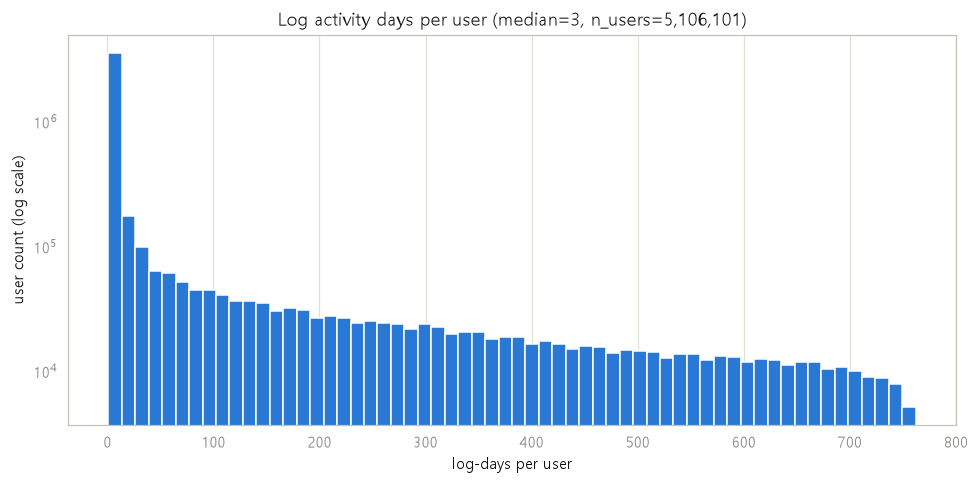

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(user_logday_counts.values, bins=60, color=SERIES_1)
ax.set_yscale("log")
ax.set_xlabel("log-days per user")
ax.set_ylabel("user count (log scale)")
ax.set_title(f"Log activity days per user (median={user_logday_counts.median():.0f}, n_users={len(user_logday_counts):,})")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

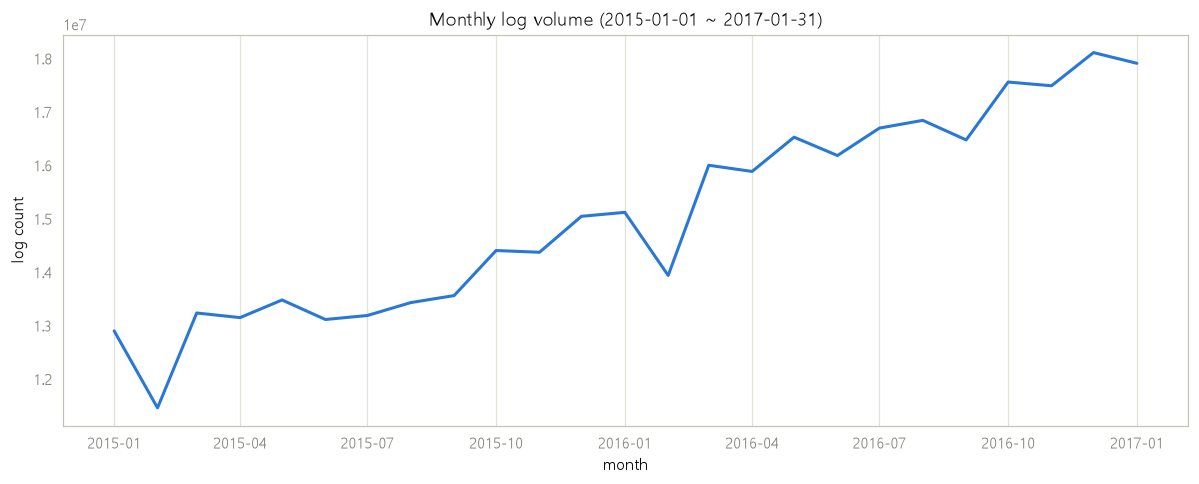

In [8]:
daily = daily_counts.copy()
daily.index = pd.to_datetime(daily.index.astype("int64").astype(str), format="%Y%m%d")
daily = daily.sort_index()
monthly_counts = daily.resample("MS").sum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly_counts.index, monthly_counts.values, color=SERIES_1, linewidth=2)
ax.set_xlabel("month")
ax.set_ylabel("log count")
ax.set_title(f"Monthly log volume ({daily.index.min().date()} ~ {daily.index.max().date()})")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

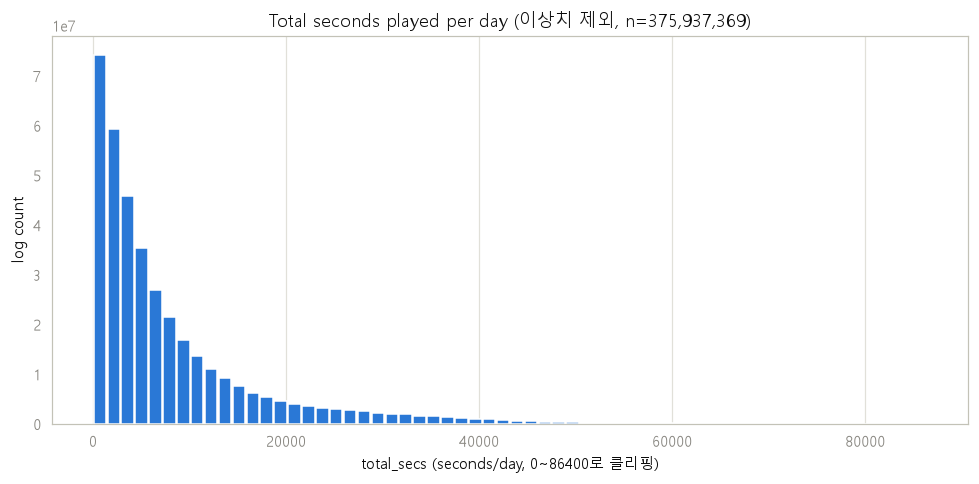

In [9]:
bin_centers = (total_secs_bins[:-1] + total_secs_bins[1:]) / 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(bin_centers, total_secs_hist, width=(total_secs_bins[1] - total_secs_bins[0]) * 0.9, color=SERIES_1)
ax.set_xlabel("total_secs (seconds/day, 0~86400로 클리핑)")
ax.set_ylabel("log count")
ax.set_title(f"Total seconds played per day (이상치 제외, n={total_secs_valid_n:,})")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

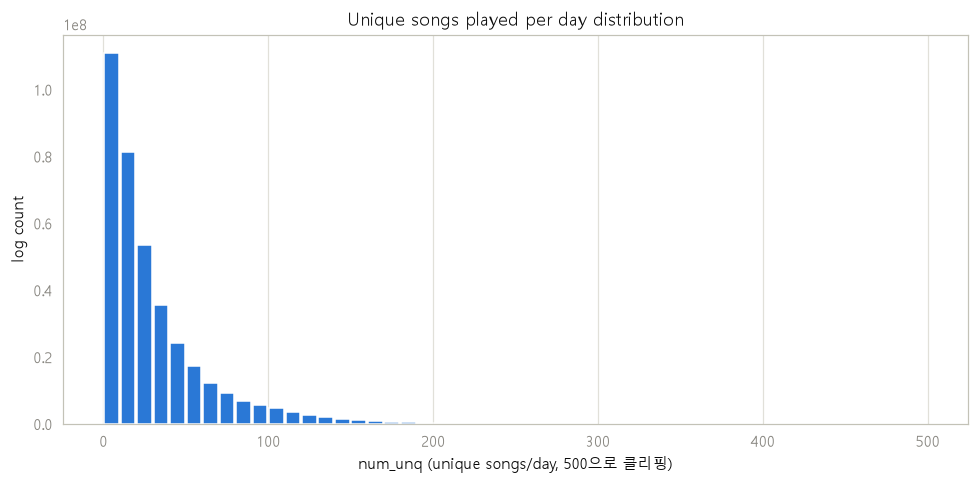

In [10]:
bin_centers = (num_unq_bins[:-1] + num_unq_bins[1:]) / 2

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(bin_centers, num_unq_hist, width=(num_unq_bins[1] - num_unq_bins[0]) * 0.9, color=SERIES_1)
ax.set_xlabel("num_unq (unique songs/day, 500으로 클리핑)")
ax.set_ylabel("log count")
ax.set_title("Unique songs played per day distribution")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

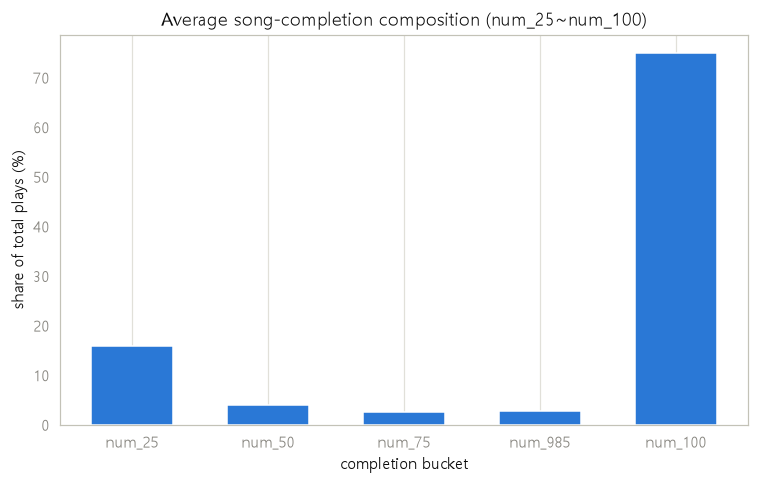

num_25     15.895698
num_50      4.005837
num_75      2.482481
num_985     2.750519
num_100    74.865465
dtype: float64

In [11]:
ratio_means = pd.Series({c: stat_sum[c] / n_rows for c in RATIO_COLS})
ratio_share = ratio_means / ratio_means.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(ratio_share.index, ratio_share.values, color=SERIES_1, width=0.6)
ax.set_xlabel("completion bucket")
ax.set_ylabel("share of total plays (%)")
ax.set_title("Average song-completion composition (num_25~num_100)")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

ratio_share

In [12]:
# ------------------------------------------------------------------
# 데이터 품질 이슈 요약 (전처리/피처엔지니어링 단계에서 처리 필요)
# 1. total_secs에 음수/센티넬성 손상 값 존재 -> 집계 전 반드시 유효 범위(0~TOTAL_SECS_CAP)로 필터링
# 2. 이 테이블도 transactions와 마찬가지로 msno 기준 1:N 구조 (유저당 여러 날짜의 로그)
#    -> 관측 종료일 2017-01-31까지의 로그만 최근 N일 윈도우로 집계해야 members/train과 병합 가능
#    원본의 2월 로그는 이탈 결과가 결정되는 미래 구간이므로 모델 입력과 EDA 통계에서 제외한다.
# 3. 용량이 매우 커서(30GB) 피처엔지니어링 단계에서도 청크 단위 처리 또는 Dask/Polars 도입을 고려해야 함
# ------------------------------------------------------------------
print("데이터 품질 이슈 요약 완료 (위 주석 참고)")

데이터 품질 이슈 요약 완료 (위 주석 참고)
